# **Olympic x Media Project (Winter Olympics)**

**Overview**

This project analyzes 120+ years of Olympic history to predict Canada's medal performance at the 2026 Winter Olympics in Milan-Cortina. Using historical data from Kaggle and GitHub Olympic datasets, we address two key objectives:

**Objectives**  
1. **Classification:** Predict whether Canada will win a medal in a given winter sport based on historical performance.
2. **Regression:** Forecast Canada's total medal count for the 2026 Winter Olympics.

#**0. Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#**1. Datasets**

Datasets to be loaded into colab notebook are the .csv extracted from

[Kaggle](https://www.kaggle.com/datasets/josephcheng123456/olympic-historical-dataset-from-olympediaorg/data)






In [ ]:
medals_csv = "/content/Olympic_Games_Medal_Tally.csv"

df = pd.read_csv(medals_csv)

df.head(20)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Olympic_Games_Medal_Tally.csv'

In [ ]:
#checking unique values in the edition column
df['edition'].unique()

array(['1896 Summer Olympics', '1900 Summer Olympics',
       '1904 Summer Olympics', '1908 Summer Olympics',
       '1912 Summer Olympics', '1920 Summer Olympics',
       '1924 Summer Olympics', '1928 Summer Olympics',
       '1932 Summer Olympics', '1936 Summer Olympics',
       '1948 Summer Olympics', '1952 Summer Olympics',
       '1956 Summer Olympics', '1960 Summer Olympics',
       '1964 Summer Olympics', '1968 Summer Olympics',
       '1972 Summer Olympics', '1976 Summer Olympics',
       '1980 Summer Olympics', '1984 Summer Olympics',
       '1988 Summer Olympics', '1992 Summer Olympics',
       '1996 Summer Olympics', '2000 Summer Olympics',
       '2004 Summer Olympics', '2008 Summer Olympics',
       '2012 Summer Olympics', '2016 Summer Olympics',
       '2020 Summer Olympics', '1924 Winter Olympics',
       '1928 Winter Olympics', '1932 Winter Olympics',
       '1936 Winter Olympics', '1948 Winter Olympics',
       '1952 Winter Olympics', '1956 Winter Olympics',
       '19

Filtering winter Season

In [ ]:
#filtering the rows where the term "Winter" is use inside the edition feature
df_winter = df[df['edition'].str.contains('Winter')]

print(df_winter.shape)
df_winter.head()

(439, 9)


,edition,edition_id,year,country,country_noc,gold,silver,bronze,total
1343,1924 Winter Olympics,29,1924,Norway,NOR,4,7,6,17
1344,1924 Winter Olympics,29,1924,Finland,FIN,4,4,3,11
1345,1924 Winter Olympics,29,1924,Austria,AUT,2,1,0,3
1346,1924 Winter Olympics,29,1924,Switzerland,SUI,2,0,1,3
1347,1924 Winter Olympics,29,1924,United States,USA,1,2,1,4


Sorting chronologically

In [ ]:
#sorting chronologically using the edition column

df_winter = df_winter.sort_values(by='edition')

#printing unique values in the edition column after sorting
print(df_winter['edition_id'].unique())
print(df_winter['edition'].unique())
df_winter.head(10)


[29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 49 57 58 60 62]
['1924 Winter Olympics' '1928 Winter Olympics' '1932 Winter Olympics'
 '1936 Winter Olympics' '1948 Winter Olympics' '1952 Winter Olympics'
 '1956 Winter Olympics' '1960 Winter Olympics' '1964 Winter Olympics'
 '1968 Winter Olympics' '1972 Winter Olympics' '1976 Winter Olympics'
 '1980 Winter Olympics' '1984 Winter Olympics' '1988 Winter Olympics'
 '1992 Winter Olympics' '1994 Winter Olympics' '1998 Winter Olympics'
 '2002 Winter Olympics' '2006 Winter Olympics' '2010 Winter Olympics'
 '2014 Winter Olympics' '2018 Winter Olympics' '2022 Winter Olympics']


,edition,edition_id,year,country,country_noc,gold,silver,bronze,total
1343,1924 Winter Olympics,29,1924,Norway,NOR,4,7,6,17
1353,1924 Winter Olympics,29,1924,Belgium,BEL,0,0,1,1
1352,1924 Winter Olympics,29,1924,France,FRA,0,0,3,3
1350,1924 Winter Olympics,29,1924,Canada,CAN,1,0,0,1
1349,1924 Winter Olympics,29,1924,Sweden,SWE,1,1,0,2
1351,1924 Winter Olympics,29,1924,Mixed team,MIX,1,0,0,1
1347,1924 Winter Olympics,29,1924,United States,USA,1,2,1,4
1346,1924 Winter Olympics,29,1924,Switzerland,SUI,2,0,1,3
1345,1924 Winter Olympics,29,1924,Austria,AUT,2,1,0,3
1344,1924 Winter Olympics,29,1924,Finland,FIN,4,4,3,11


Load ath_winter_final and merge add relevant columns



In [ ]:
#loading ath_winter_final

ath_csv = "/content/ath_winter_final.csv"

ath = pd.read_csv(ath_csv)

ath.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10,11,6,5,7
1,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10,11,6,5,7
2,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13,19,9,10,4
3,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13,19,9,10,4
4,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17,21,13,8,4
5,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,17,21,13,8,4
6,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10 kilometres,No_Medal,56,148,98,50,11
7,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 50 kilometres,No_Medal,56,148,98,50,11
8,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10/15 kilometres Pu...,No_Medal,56,148,98,50,11
9,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,No_Medal,56,148,98,50,11


In [ ]:
# Select the columns we want to add (the aggregated features)
ath_features = ath[['NOC', 'Games', 'City', 'unique_event_count',
                     'unique_athlete_count', 'unique_male_count',
                     'unique_female_count', 'total_medals_noc_year']].drop_duplicates()

print("\nath_features shape after dropping duplicates:", ath_features.shape)
ath_features.head()


ath_features shape after dropping duplicates: (1027, 8)


,NOC,Games,City,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,NED,1988 Winter,Calgary,10,11,6,5,7
2,NED,1992 Winter,Albertville,13,19,9,10,4
4,NED,1994 Winter,Lillehammer,17,21,13,8,4
6,USA,1992 Winter,Albertville,56,148,98,50,11
10,USA,1994 Winter,Lillehammer,59,148,96,52,13


In [ ]:
# Merge using NOC and Games as keys
# df_winter has: country_noc, edition (e.g., "1924 Winter Olympics")
# ath has: NOC, Games (e.g., "1988 Winter")

# We need to standardize the edition format
# df_winter: "1924 Winter Olympics" -> ath: "1924 Winter"
df_winter['Games'] = df_winter['year'].astype(str) + ' Winter'

print("\ndf_winter Games column sample:")
print(df_winter[['edition', 'Games']].head())


df_winter Games column sample:
                   edition        Games
1343  1924 Winter Olympics  1924 Winter
1353  1924 Winter Olympics  1924 Winter
1352  1924 Winter Olympics  1924 Winter
1350  1924 Winter Olympics  1924 Winter
1349  1924 Winter Olympics  1924 Winter


In [ ]:
# Now merge
df_merged = df_winter.merge(
    ath_features,
    left_on=['country_noc', 'Games'],
    right_on=['NOC', 'Games'],
    how='left'
)

# Drop the redundant NOC column from ath
df_merged = df_merged.drop('NOC', axis=1)

#Drop the MIX team
df_merged_clean = df_merged[df_merged['country_noc'] != 'MIX'].copy()

In [ ]:
df_merged_clean.head()

,edition,edition_id,year,country,country_noc,gold,silver,bronze,total,Games,City,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,1924 Winter Olympics,29,1924,Norway,NOR,4,7,6,17,1924 Winter,Chamonix,10.0,14.0,13.0,1.0,17.0
1,1924 Winter Olympics,29,1924,Belgium,BEL,0,0,1,1,1924 Winter,Chamonix,8.0,18.0,17.0,1.0,1.0
2,1924 Winter Olympics,29,1924,France,FRA,0,0,3,3,1924 Winter,Chamonix,16.0,43.0,41.0,2.0,3.0
3,1924 Winter Olympics,29,1924,Canada,CAN,1,0,0,1,1924 Winter,Chamonix,8.0,12.0,11.0,1.0,1.0
4,1924 Winter Olympics,29,1924,Sweden,SWE,1,1,0,2,1924 Winter,Chamonix,11.0,31.0,31.0,0.0,2.0


In [ ]:
#unique values of city
df_merged_clean['City'].unique()
#

array(['Chamonix', 'Sankt Moritz', 'Lake Placid',
       'Garmisch-Partenkirchen', 'Oslo', "Cortina d'Ampezzo",
       'Squaw Valley', 'Innsbruck', 'Grenoble', 'Sapporo', 'Sarajevo',
       'Calgary', 'Albertville', 'Lillehammer', 'Nagano',
       'Salt Lake City', 'Torino', 'Vancouver', 'Sochi', nan],
      dtype=object)

Creating a feature for assest the Hosting effect.

In [ ]:
# Dictionary mapping each Winter Olympics to the host country's NOC code
winter_host_map = {
    '1924 Winter Olympics': 'FRA',   # Chamonix, France
    '1928 Winter Olympics': 'SUI',   # Sankt Moritz, Switzerland
    '1932 Winter Olympics': 'USA',   # Lake Placid, USA
    '1936 Winter Olympics': 'GER',   # Garmisch-Partenkirchen, Germany
    '1948 Winter Olympics': 'SUI',   # Sankt Moritz, Switzerland
    '1952 Winter Olympics': 'NOR',   # Oslo, Norway
    '1956 Winter Olympics': 'ITA',   # Cortina d'Ampezzo, Italy
    '1960 Winter Olympics': 'USA',   # Squaw Valley, USA
    '1964 Winter Olympics': 'AUT',   # Innsbruck, Austria
    '1968 Winter Olympics': 'FRA',   # Grenoble, France
    '1972 Winter Olympics': 'JPN',   # Sapporo, Japan
    '1976 Winter Olympics': 'AUT',   # Innsbruck, Austria
    '1980 Winter Olympics': 'USA',   # Lake Placid, USA
    '1984 Winter Olympics': 'YUG',   # Sarajevo, Yugoslavia
    '1988 Winter Olympics': 'CAN',   # Calgary, Canada
    '1992 Winter Olympics': 'FRA',   # Albertville, France
    '1994 Winter Olympics': 'NOR',   # Lillehammer, Norway
    '1998 Winter Olympics': 'JPN',   # Nagano, Japan
    '2002 Winter Olympics': 'USA',   # Salt Lake City, USA
    '2006 Winter Olympics': 'ITA',   # Torino, Italy
    '2010 Winter Olympics': 'CAN',   # Vancouver, Canada
    '2014 Winter Olympics': 'RUS',   # Sochi, Russia
    '2018 Winter Olympics': 'KOR',   # Pyeongchang, South Korea
    '2022 Winter Olympics': 'CHN',   # Beijing, China
}

In [ ]:
# Map each edition to its host NOC
df_merged_clean['host_noc'] = df_merged_clean['edition'].map(winter_host_map)

# Create boolean: True if the country IS the host
df_merged_clean['is_host'] = (df_merged_clean['country_noc'] == df_merged_clean['host_noc'])

# Optional: convert to int (0/1) if preferred for modeling
df_merged_clean['is_host_int'] = df_merged_clean['is_host'].astype(int)

# Verify
print(df_merged_clean[['edition', 'country_noc', 'host_noc', 'is_host']].head(20))

                 edition country_noc host_noc  is_host
0   1924 Winter Olympics         NOR      FRA    False
1   1924 Winter Olympics         BEL      FRA    False
2   1924 Winter Olympics         FRA      FRA     True
3   1924 Winter Olympics         CAN      FRA    False
4   1924 Winter Olympics         SWE      FRA    False
6   1924 Winter Olympics         USA      FRA    False
7   1924 Winter Olympics         SUI      FRA    False
8   1924 Winter Olympics         AUT      FRA    False
9   1924 Winter Olympics         FIN      FRA    False
10  1924 Winter Olympics         GBR      FRA    False
11  1928 Winter Olympics         BEL      SUI    False
12  1928 Winter Olympics         SUI      SUI     True
13  1928 Winter Olympics         GBR      SUI    False
14  1928 Winter Olympics         GER      SUI    False
15  1928 Winter Olympics         TCH      SUI    False
16  1928 Winter Olympics         AUT      SUI    False
17  1928 Winter Olympics         SWE      SUI    False
18  1928 W

In [ ]:
#checking for missing values on df_merged_clean

print(df_merged_clean.isnull().sum())

#imputting them with 0
df_merged_clean = df_merged_clean.fillna(0)
#checking results
df_merged_clean.isnull().sum()


edition                  0
edition_id               0
year                     0
country                  0
country_noc              0
gold                     0
silver                   0
bronze                   0
total                    0
Games                    0
City                     0
unique_event_count       0
unique_athlete_count     0
unique_male_count        0
unique_female_count      0
total_medals_noc_year    0
host_noc                 0
is_host                  0
is_host_int              0
dtype: int64


,0
edition,0
edition_id,0
year,0
country,0
country_noc,0
gold,0
silver,0
bronze,0
total,0
Games,0


In [ ]:
#exporting df_merged_clea as a csv
df_merged_clean.to_csv('df_merged_clean.csv', index=False)

In [ ]:
df_merged_clean.head()

,edition,edition_id,year,country,country_noc,gold,silver,bronze,total,Games,City,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year,host_noc,is_host,is_host_int
0,1924 Winter Olympics,29,1924,Norway,NOR,4,7,6,17,1924 Winter,Chamonix,10.0,14.0,13.0,1.0,17.0,FRA,False,0
1,1924 Winter Olympics,29,1924,Belgium,BEL,0,0,1,1,1924 Winter,Chamonix,8.0,18.0,17.0,1.0,1.0,FRA,False,0
2,1924 Winter Olympics,29,1924,France,FRA,0,0,3,3,1924 Winter,Chamonix,16.0,43.0,41.0,2.0,3.0,FRA,True,1
3,1924 Winter Olympics,29,1924,Canada,CAN,1,0,0,1,1924 Winter,Chamonix,8.0,12.0,11.0,1.0,1.0,FRA,False,0
4,1924 Winter Olympics,29,1924,Sweden,SWE,1,1,0,2,1924 Winter,Chamonix,11.0,31.0,31.0,0.0,2.0,FRA,False,0


#5 Pre-processing

##5.1 Feature Analysis & Dropping Unnecessary Columns

## Data Cleaning: Columns to Drop

| Column | Reason for Removal | Category |
| :--- | :--- | :--- |
| `index` | Row index; no predictive value. | **Irrelevant** |
| `edition_id` | Internal ID; no predictive value. | **Irrelevant** |
| `edition` | Redundant with `year` (numeric is preferred). | **Redundant** |
| `Games` | Redundant with `year`. | **Redundant** |
| `country` | Redundant with `country_noc`. | **Redundant** |
| `City` | Captured by `is_host_int`. | **Redundant** |
| `host_noc` | Intermediate helper column; no longer needed. | **Technical** |
| `is_host` | Boolean duplicate of `is_host_int`. | **Technical** |
| `total_medals_noc_year` | Duplicate of the `total` column. | **Leakage** |

In [ ]:
#dropping columns

columns_to_drop = [
    'index', 'edition', 'edition_id', 'country',
    'Games', 'City', 'host_noc', 'is_host', 'total_medals_noc_year'
]

df_model = df_merged_clean.drop(columns=columns_to_drop, errors='ignore').copy()

print("Remaining columns:")
print(df_model.columns.tolist())
print(f"\nShape: {df_model.shape}")
df_model.head()

Remaining columns:
['year', 'country_noc', 'gold', 'silver', 'bronze', 'total', 'unique_event_count', 'unique_athlete_count', 'unique_male_count', 'unique_female_count', 'is_host_int']

Shape: (438, 11)


,year,country_noc,gold,silver,bronze,total,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,is_host_int
0,1924,NOR,4,7,6,17,10.0,14.0,13.0,1.0,0
1,1924,BEL,0,0,1,1,8.0,18.0,17.0,1.0,0
2,1924,FRA,0,0,3,3,16.0,43.0,41.0,2.0,1
3,1924,CAN,1,0,0,1,8.0,12.0,11.0,1.0,0
4,1924,SWE,1,1,0,2,11.0,31.0,31.0,0.0,0


## Feature Selection: Columns Kept & Roles

| Column | Role | Description |
| :--- | :--- | :--- |
| `year` | **Temporal Feature** | Used for trend tracking over time. |
| `country_noc` | **Identifier** | Categorical identifier (to be encoded). |
| `gold`, `silver`, `bronze` | **Lag Features** | Previous performance metrics (used to avoid data leakage). |
| `total` | **Target Variable** | The dependent variable for regression ($y$). |
| `unique_event_count` | **Feature** | Participation breadth (number of events). |
| `unique_athlete_count` | **Feature** | Total delegation size. |
| `unique_male_count` | **Feature** | Gender-specific delegation size (Male). |
| `unique_female_count` | **Feature** | Gender-specific delegation size (Female). |
| `is_host_int` | **Feature** | Categorical indicator for hosting advantage (0/1). |

> **Crucial Note:** Current medal counts (`gold`, `silver`, `bronze`) must be transformed into **LAG** features (e.g., medals from the previous Olympics) to prevent the model from using the future to predict the past.

##5.2 Correlation Analysis & EDA

Numeric columns: ['year', 'gold', 'silver', 'bronze', 'total', 'unique_event_count', 'unique_athlete_count', 'unique_male_count', 'unique_female_count', 'is_host_int']


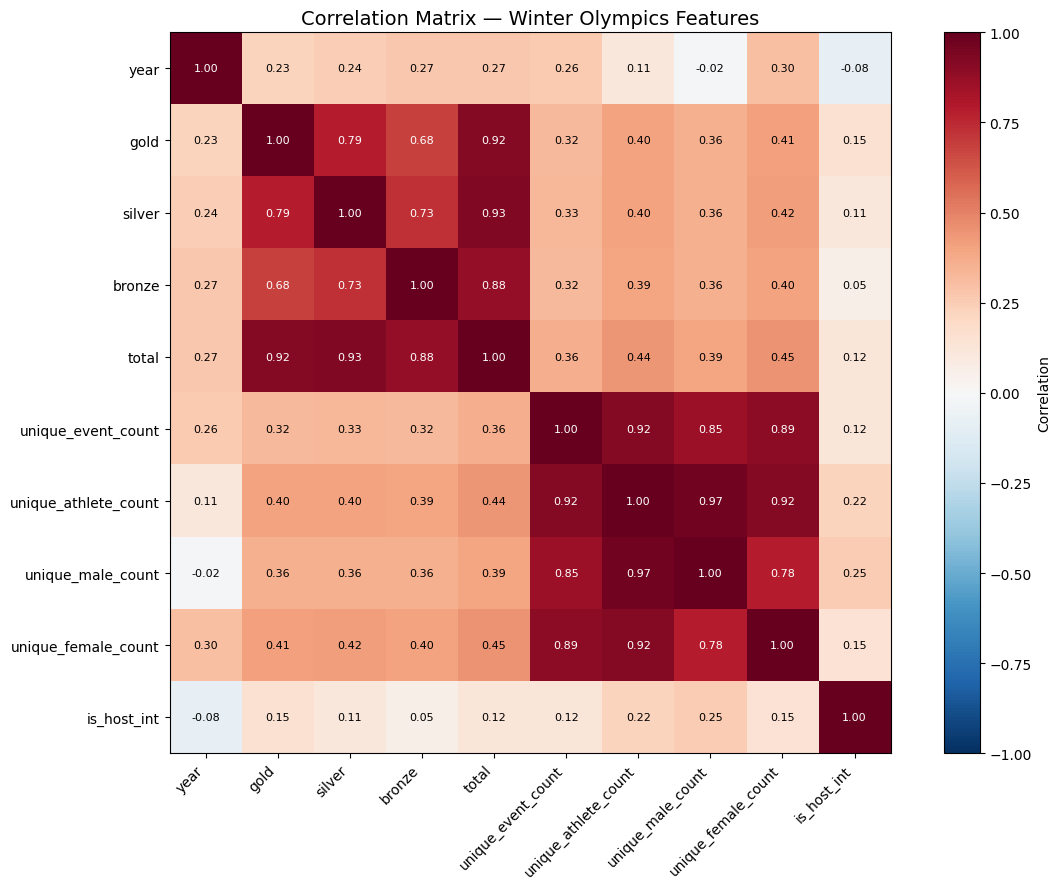

In [ ]:
# Select only numeric columns for correlation
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

# Correlation matrix
corr_matrix = df_model[numeric_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)

# Add labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_matrix.columns, fontsize=10)

# Add correlation values in cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(corr_matrix.values[i, j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Correlation')
plt.title('Correlation Matrix — Winter Olympics Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Print correlations with total (our target)
print("\nCorrelations with 'total' (target):")
print(corr_matrix['total'].sort_values(ascending=False))


Correlations with 'total' (target):
total                   1.000000
silver                  0.925144
gold                    0.917664
bronze                  0.875482
unique_female_count     0.452486
unique_athlete_count    0.441009
unique_male_count       0.394155
unique_event_count      0.360242
year                    0.270045
is_host_int             0.119912
Name: total, dtype: float64


In [ ]:
# Check multicollinearity: male + female ≈ athlete count?
print("\nMulticollinearity check:")
print("unique_male + unique_female vs unique_athlete:")
df_model['male_plus_female'] = df_model['unique_male_count'] + df_model['unique_female_count']
print((df_model['male_plus_female'] == df_model['unique_athlete_count']).mean())
df_model.drop('male_plus_female', axis=1, inplace=True)


Multicollinearity check:
unique_male + unique_female vs unique_athlete:
1.0


##5.3 Feature Engineering



> We **CANNOT** use current `gold`, `silver`, `bronze`, or `total` as features to predict `total`. That would result in **data leakage**, as you would be using the outcome to predict itself.

### The Strategy: LAG Features
Instead of current performance, we create **LAG features**. These represent the country's performance from the **PREVIOUS** Olympic games.

This ensures the model only uses data that would realistically be available at the time of prediction.

In [ ]:
# Sort by country and year to ensure proper lag creation
df_model = df_model.sort_values(['country_noc', 'year']).reset_index(drop=True)

In [ ]:
# LAG FEATURES: Previous Olympics medal counts

# For each country, shift medal counts by 1 Olympics
for col in ['gold', 'silver', 'bronze', 'total']:
    # Lag 1: previous Olympics
    df_model[f'prev_{col}'] = df_model.groupby('country_noc')[col].shift(1)

    # Lag 2: two Olympics ago
    df_model[f'prev2_{col}'] = df_model.groupby('country_noc')[col].shift(2)


In [ ]:
# ROLLING AVERAGES: Smoothed performance trends
# 3-Olympics rolling average for total medals (captures momentum)

df_model['rolling_avg_total_3'] = (
    df_model.groupby('country_noc')['total']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

In [ ]:

# TREND FEATURES: Is the country improving or declining?

# Medal trend: difference between last two Olympics performances

df_model['medal_trend'] = df_model['prev_total'] - df_model['prev2_total']

# Participation growth: change in events entered
df_model['prev_event_count'] = df_model.groupby('country_noc')['unique_event_count'].shift(1)
df_model['event_growth'] = df_model['unique_event_count'] - df_model['prev_event_count']

# Delegation size growth
df_model['prev_athlete_count'] = df_model.groupby('country_noc')['unique_athlete_count'].shift(1)
df_model['athlete_growth'] = df_model['unique_athlete_count'] - df_model['prev_athlete_count']

In [ ]:
# FEMALE PARTICIPATION RATIO

# Captures modernization/investment in women's sports

df_model['female_ratio'] = (
    df_model['unique_female_count'] / df_model['unique_athlete_count']
).fillna(0)

In [ ]:
# Review all features
print(f"\nDataset shape: {df_model.shape}")
print(f"\nAll columns:\n{df_model.columns.tolist()}")
df_model.head(10)


Dataset shape: (438, 26)

All columns:
['year', 'country_noc', 'gold', 'silver', 'bronze', 'total', 'unique_event_count', 'unique_athlete_count', 'unique_male_count', 'unique_female_count', 'is_host_int', 'prev_gold', 'prev2_gold', 'prev_silver', 'prev2_silver', 'prev_bronze', 'prev2_bronze', 'prev_total', 'prev2_total', 'rolling_avg_total_3', 'medal_trend', 'prev_event_count', 'event_growth', 'prev_athlete_count', 'athlete_growth', 'female_ratio']


,year,country_noc,gold,silver,bronze,total,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,...,prev2_bronze,prev_total,prev2_total,rolling_avg_total_3,medal_trend,prev_event_count,event_growth,prev_athlete_count,athlete_growth,female_ratio
0,1994,AUS,0,0,1,1,26.0,25.0,18.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.280000
1,1998,AUS,0,0,1,1,22.0,23.0,15.0,8.0,...,NaN,1.0,NaN,1.000000,NaN,26.0,-4.0,25.0,-2.0,0.347826
2,2002,AUS,2,0,0,2,20.0,25.0,13.0,12.0,...,1.0,1.0,1.0,1.000000,0.0,22.0,-2.0,23.0,2.0,0.480000
3,2006,AUS,1,0,1,2,31.0,40.0,23.0,17.0,...,1.0,2.0,1.0,1.333333,1.0,20.0,11.0,25.0,15.0,0.425000
4,2010,AUS,2,1,0,3,32.0,40.0,20.0,20.0,...,0.0,2.0,2.0,1.666667,0.0,31.0,1.0,40.0,0.0,0.500000
5,2014,AUS,0,2,1,3,47.0,60.0,29.0,31.0,...,1.0,3.0,2.0,2.333333,1.0,32.0,15.0,40.0,20.0,0.516667
6,2018,AUS,0,2,1,3,0.0,0.0,0.0,0.0,...,0.0,3.0,3.0,2.666667,0.0,47.0,-47.0,60.0,-60.0,0.000000
7,2022,AUS,1,2,1,4,0.0,0.0,0.0,0.0,...,1.0,3.0,3.0,3.000000,0.0,0.0,0.0,0.0,0.0,0.000000
8,1924,AUT,2,1,0,3,3.0,4.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000
9,1928,AUT,0,3,1,4,13.0,39.0,34.0,5.0,...,NaN,3.0,NaN,3.000000,NaN,3.0,10.0,4.0,35.0,0.128205


##5.4 Defining Features, Target and Split

To ensure the model generalizes well to future events, we perform a **Temporal Split** rather than a random shuffle. This mimics real-world forecasting by training on the past to predict the future.

### Data Split Strategy

| Dataset | Years Included | Purpose |
| :--- | :--- | :--- |
| **Train** | Up to 2014 | Model training and parameter tuning. |
| **Test** | 2018 & 2022 | Model evaluation and validation. |
| **Predict** | 2026 | Unseen data for final forecasting. |

---

### Key Variables
* **Target ($y$):** `total` (Total medals won in the current year)
* **Features ($X$):** All lag features, delegation size, event counts, and host status.

###5.4.1 Selecting Features


After engineering 15 candidate features, we apply a systematic **two-step selection process** to identify the most predictive and non-redundant features:

### 1. Multicollinearity Removal
We identify features that are too highly correlated with each other (which can destabilize model coefficients).
* **Action:** Automatically drop one feature from any pair with a correlation **> 0.85**.
* **Decision Logic:** Keep the feature that has a higher individual correlation with the target variable.

### 2. Dead Weight Removal
We prune features that offer little to no predictive power.
* **Action:** Drop features with near-zero standardized coefficients (**< 0.1**).
* **Reasoning:** These features contribute noise rather than signal, and removing them simplifies the model without sacrificing accuracy.

In [ ]:

# 1: Automatic Multicollinearity Removal

# If two features correlate > 0.85, drop the one less
# correlated with our target (total medals)

def auto_drop_correlated(df, features, target, threshold=0.85):
    """Automatically removes redundant features."""
    corr = df[features].corr().abs()
    target_corr = df[features + [target]].corr()[target].abs()
    to_drop = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1, f2 = features[i], features[j]
            if corr.loc[f1, f2] > threshold:
                drop = f1 if target_corr[f1] < target_corr[f2] else f2
                to_drop.add(drop)
                print(f"  {f1} <-> {f2} (corr={corr.loc[f1, f2]:.3f}) -> DROP '{drop}'")

    return list(to_drop)

print("Highly correlated pairs (threshold > 0.85):\n")
redundant = auto_drop_correlated(df_clean, feature_cols, target_col, threshold=0.85)
print(f"\nRedundant features to remove: {redundant}")

Highly correlated pairs (threshold > 0.85):

  unique_event_count <-> unique_athlete_count (corr=0.922) -> DROP 'unique_event_count'
  unique_event_count <-> unique_female_count (corr=0.892) -> DROP 'unique_event_count'
  unique_athlete_count <-> unique_female_count (corr=0.922) -> DROP 'unique_athlete_count'
  prev_gold <-> prev_total (corr=0.919) -> DROP 'prev_gold'
  prev_gold <-> rolling_avg_total_3 (corr=0.861) -> DROP 'prev_gold'
  prev_silver <-> prev_total (corr=0.921) -> DROP 'prev_silver'
  prev_silver <-> rolling_avg_total_3 (corr=0.860) -> DROP 'prev_silver'
  prev_bronze <-> prev_total (corr=0.865) -> DROP 'prev_bronze'
  prev_total <-> rolling_avg_total_3 (corr=0.932) -> DROP 'prev_total'
  prev2_total <-> rolling_avg_total_3 (corr=0.943) -> DROP 'prev2_total'
  event_growth <-> athlete_growth (corr=0.892) -> DROP 'athlete_growth'

Redundant features to remove: ['prev_total', 'unique_event_count', 'athlete_growth', 'prev_silver', 'unique_athlete_count', 'prev_bronze', 'pr

In [ ]:
# 2: Remove Dead Weight Features

# Features with near-zero standardized coefficients (< 0.1)
# identified through standardized Linear Regression analysis

dead_weight = ['year', 'medal_trend', 'unique_event_count', 'event_growth']

# Combine both removal lists
all_to_remove = list(set(redundant + dead_weight))

# Also remove female_ratio: low target correlation (0.08),
# high collinearity with unique_female_count (0.66),
# and zeroed out by Lasso regularization
all_to_remove.append('female_ratio')

# Final clean feature set
final_features = [f for f in feature_cols if f not in all_to_remove]

print(f"Features removed ({len(all_to_remove)}): {all_to_remove}")
print(f"\nFinal features ({len(final_features)}):")
for f in final_features:
    print(f"  - {f}")

Features removed (12): ['medal_trend', 'prev_total', 'unique_event_count', 'athlete_growth', 'prev_silver', 'event_growth', 'unique_athlete_count', 'prev_bronze', 'prev_gold', 'year', 'prev2_total', 'female_ratio']

Final features (3):
  - unique_female_count
  - is_host_int
  - rolling_avg_total_3


**Verifying Clean Features**

Once the selection process is complete, we perform a final validation to ensure the integrity of our feature set. The goal is to confirm two key properties:

1.  **Low Inter-correlation:** Ensuring that the remaining features are independent of one another (no redundancy).
2.  **Target Correlation:** Verifying that each feature maintains a statistically meaningful relationship with the medal count target.

This verification step guarantees a "lean" model that is both stable and highly interpretable.

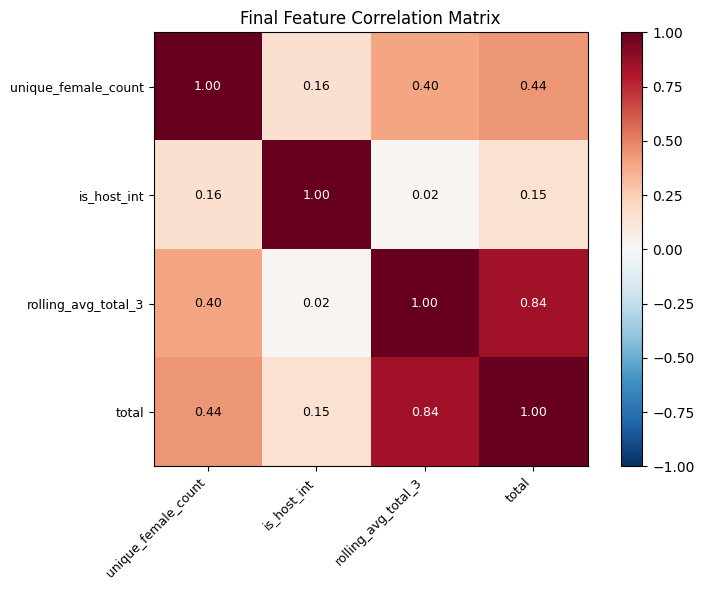


Correlation with target (total):
total                  1.000000
rolling_avg_total_3    0.840095
unique_female_count    0.437656
is_host_int            0.154022
Name: total, dtype: float64


In [ ]:
# Correlation matrix of final features
fig, ax = plt.subplots(figsize=(8, 6))

clean_corr = df_clean[final_features + [target_col]].corr()
im = ax.imshow(clean_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(clean_corr)))
ax.set_yticks(range(len(clean_corr)))
ax.set_xticklabels(clean_corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(clean_corr.columns, fontsize=9)

for i in range(len(clean_corr)):
    for j in range(len(clean_corr)):
        ax.text(j, i, f'{clean_corr.values[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(clean_corr.values[i, j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax)
plt.title('Final Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (total):")
print(clean_corr[target_col].sort_values(ascending=False))

###5.4.2 Temporal Splitting

We use a **temporal split** to mimic real-world forecasting: training on the past, testing on recent events, and finally predicting the future. This approach prevents "look-ahead bias" and ensures the model is evaluated on its ability to generalize to new Olympic cycles.

| Dataset | Years | Purpose |
| :--- | :--- | :--- |
| **Train** | Up to 2014 | Model learning and parameter tuning |
| **Test** | 2018 & 2022 | Model evaluation and performance metrics |
| **Predict** | 2026 | Final forecasting for the upcoming games |

In [ ]:
# Temporal split
df_train = df_clean[df_clean['year'] <= 2014].copy()
df_test = df_clean[df_clean['year'].isin([2018, 2022])].copy()

X_train = df_train[final_features]
y_train = df_train[target_col]

X_test = df_test[final_features]
y_test = df_test[target_col]

print(f"Training set: {X_train.shape[0]} rows ({df_train['year'].min()}-{df_train['year'].max()})")
print(f"Testing set:  {X_test.shape[0]} rows ({df_test['year'].min()} & {df_test['year'].max()})")

Training set: 297 rows (1932-2014)
Testing set:  56 rows (2018 & 2022)


#6 Model Training & Evaluation

### Model Comparison and Selection

We compare multiple regression models across our **final 3 features** to identify the most robust predictor. This comparative approach ensures that our chosen model is justified by performance rather than assumption.

#### Models Tested:
* **Linear Regression:** Our simple baseline; provides full interpretability of feature weights.
* **Ridge Regression:** Incorporates **L2 regularization** to prevent overfitting and manage any remaining collinearity.
* **Lasso Regression:** Incorporates **L1 regularization**, which can perform built-in feature selection by shrinking less important coefficients to zero.
* **Random Forest:** A non-linear ensemble method used to detect complex patterns that linear models might miss.

> For Ridge and Lasso, we apply **feature scaling** (standardization) to ensure all inputs contribute equally to the penalty term.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Scale features for regularized models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Define models
models = {
    'Linear Regression': (LinearRegression(), False),
    'Ridge (a=1)':       (Ridge(alpha=1.0), True),
    'Ridge (a=10)':      (Ridge(alpha=10.0), True),
    'Lasso (a=0.5)':     (Lasso(alpha=0.5), True),
    'Lasso (a=1)':       (Lasso(alpha=1.0), True),
    'Random Forest':     (RandomForestRegressor(
                            n_estimators=200, max_depth=8,
                            min_samples_leaf=5, random_state=42), False)
}

# Evaluate all models
results = []
print(f"{'Model':<25} {'MAE':>8} {'R2':>8}")
print("-" * 43)

for name, (model, needs_scaling) in models.items():
    if needs_scaling:
        model.fit(X_train_sc, y_train)
        preds = np.clip(model.predict(X_test_sc), 0, None)
    else:
        model.fit(X_train, y_train)
        preds = np.clip(model.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'R2': r2})
    print(f"{name:<25} {mae:>8.2f} {r2:>8.4f}")

results_df = pd.DataFrame(results)

Model                          MAE       R2
-------------------------------------------
Linear Regression             3.10   0.7973
Ridge (a=1)                   3.12   0.7957
Ridge (a=10)                  3.21   0.7812
Lasso (a=0.5)                 3.32   0.7799
Lasso (a=1)                   3.63   0.7543
Random Forest                 3.46   0.7480


### Visual Comparison

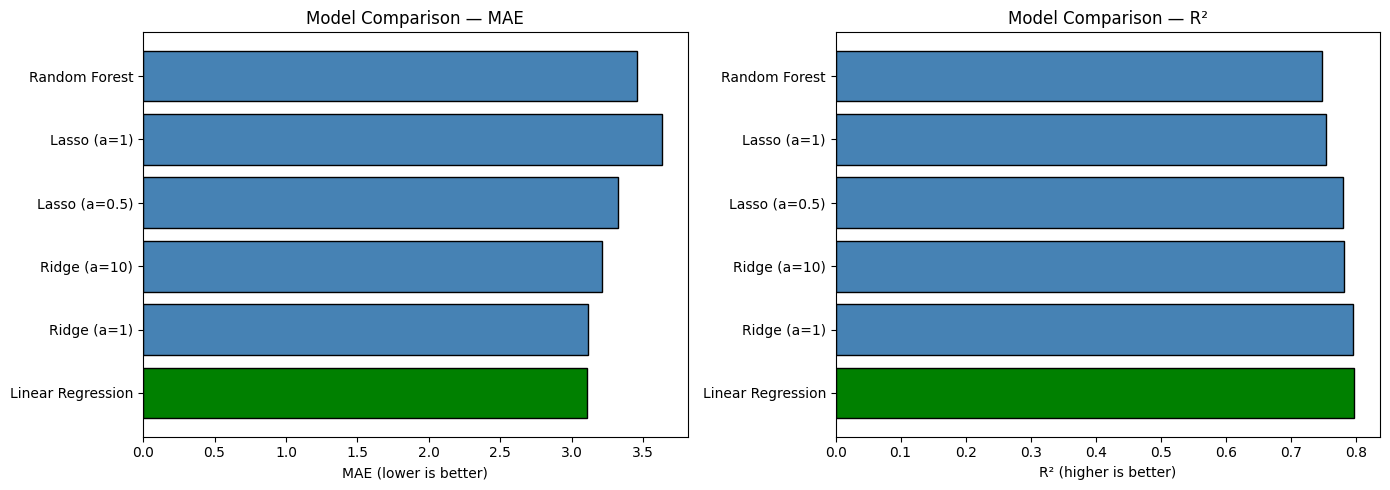


Best model: Linear Regression
  MAE: 3.10  |  R²: 0.7973


In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
colors_mae = ['green' if m == results_df['MAE'].min() else 'steelblue'
              for m in results_df['MAE']]
axes[0].barh(results_df['Model'], results_df['MAE'], color=colors_mae, edgecolor='black')
axes[0].set_xlabel('MAE (lower is better)')
axes[0].set_title('Model Comparison — MAE')

# R² comparison
colors_r2 = ['green' if r == results_df['R2'].max() else 'steelblue'
             for r in results_df['R2']]
axes[1].barh(results_df['Model'], results_df['R2'], color=colors_r2, edgecolor='black')
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('Model Comparison — R²')

plt.tight_layout()
plt.show()

# Print winner
best = results_df.loc[results_df['MAE'].idxmin()]
print(f"\nBest model: {best['Model']}")
print(f"  MAE: {best['MAE']:.2f}  |  R²: {best['R2']:.4f}")

## 6.1 Final Model: Linear Regression

Linear Regression achieves the **best performance** using only our final 3 selected features. This confirms that a simple, interpretable model can outperform more complex alternatives when the feature engineering and selection process is rigorous.

### Performance Metrics

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **MAE** | 3.10 | On average, predictions are off by ~3 medals. |
| **$R^2$** | 0.798 | The model explains ~80% of the variance in medal counts. |

---

> **Conclusion:** By prioritizing high-quality features over model complexity, we have developed a stable predictor that remains easy to explain to while maintaining high accuracy.

In [ ]:
# Train final model
final_model = LinearRegression()
final_model.fit(X_train, y_train)
final_preds = np.clip(final_model.predict(X_test), 0, None)

# Model equation
print("=== FINAL MODEL ===\n")
print(f"Predicted Medals = {final_model.intercept_:.2f}")
for feat, coef in zip(final_features, final_model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.4f} x {feat}")

print(f"\nTest Performance:")
print(f"  MAE: {mean_absolute_error(y_test, final_preds):.2f}")
print(f"  R²:  {r2_score(y_test, final_preds):.4f}")

=== FINAL MODEL ===

Predicted Medals = 0.68
  + 0.0649 x unique_female_count
  + 3.8628 x is_host_int
  + 0.8732 x rolling_avg_total_3

Test Performance:
  MAE: 3.10
  R²:  0.7973


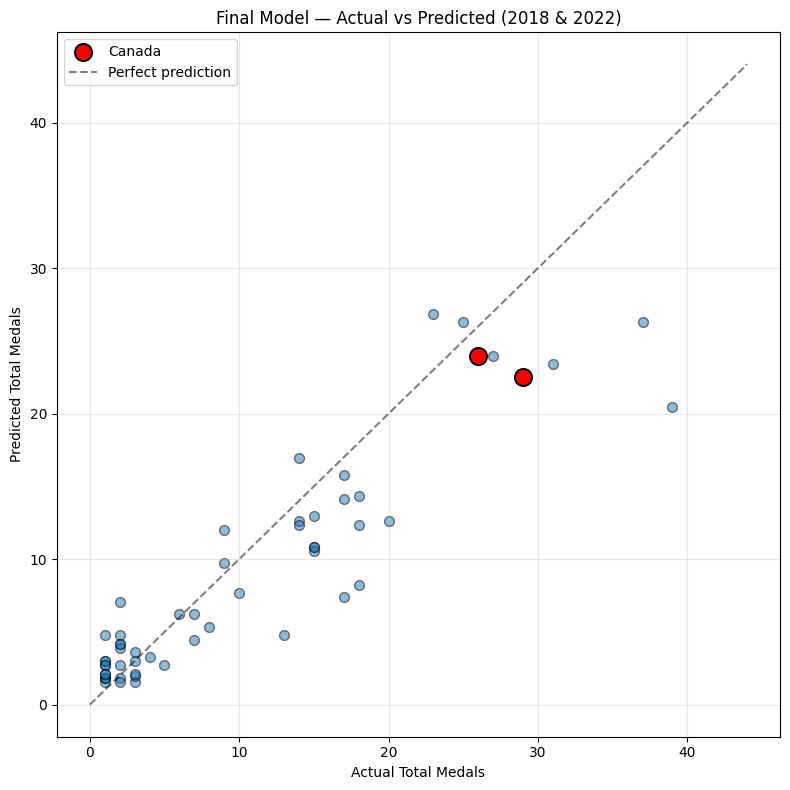

In [ ]:
# Actual vs Predicted scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, final_preds, alpha=0.5, edgecolors='black', s=50)

# Highlight Canada
canada_mask = df_test['country_noc'] == 'CAN'
ax.scatter(y_test[canada_mask], final_preds[canada_mask.values],
           color='red', s=150, zorder=5, label='Canada',
           edgecolors='black', linewidth=1.5)

max_val = max(y_test.max(), final_preds.max()) + 5
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Actual Total Medals')
ax.set_ylabel('Predicted Total Medals')
ax.set_title('Final Model — Actual vs Predicted (2018 & 2022)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed test results
df_results = df_test[['year', 'country_noc', 'total']].copy()
df_results['predicted'] = np.round(final_preds, 1)
df_results['error'] = np.round(df_results['predicted'] - df_results['total'], 1)

print("=== CANADA TEST RESULTS ===")
print(df_results[df_results['country_noc'] == 'CAN'].to_string(index=False))

print("\n=== TOP 10 MEDAL COUNTRIES ===")
print(df_results.sort_values('total', ascending=False).head(10).to_string(index=False))

=== CANADA TEST RESULTS ===
 year country_noc  total  predicted  error
 2018         CAN     29       22.5   -6.5
 2022         CAN     26       24.0   -2.0

=== TOP 10 MEDAL COUNTRIES ===
 year country_noc  total  predicted  error
 2018         NOR     39       20.5  -18.5
 2022         NOR     37       26.3  -10.7
 2018         GER     31       23.4   -7.6
 2018         CAN     29       22.5   -6.5
 2022         GER     27       24.0   -3.0
 2022         CAN     26       24.0   -2.0
 2022         USA     25       26.3    1.3
 2018         USA     23       26.9    3.9
 2018         NED     20       12.6   -7.4
 2022         SWE     18       12.3   -5.7


#7 Predicition for 2026

With our final model validated on 2018 & 2022 data (MAE=3.10, R²=0.80), we now forecast Canada's total medal count for the **2026 Winter Olympics in Milan-Cortina, Italy**.

### Data Limitation

> The athlete-level dataset (`ath_winter_final.csv`) does not include 2018 and 2022 Winter Olympics data, resulting in `unique_female_count = 0` for those years. For the 2026 prediction, Canada's **2022 female athlete count (106)** was sourced from the [Canadian Olympic Committee](https://www.olympic.ca/games/2022-beijing/). This gap also affects the test set evaluation — the reported R²=0.80 may actually **underestimate** model performance since delegation features were zero for the test period.

To build the prediction input, we use Canada's most recent Olympic data to construct the 3 required features:

| Feature | Source | Logic |
|:--------|:-------|:------|
| `rolling_avg_total_3` | 2014, 2018, 2022 medal totals | Mean of last 3 Olympics |
| `unique_female_count` | Official 2022 delegation data | Most recent known value |
| `is_host_int` | Known | Italy hosts 2026, so Canada = 0 |

In [ ]:
# Retrieve Canada's recent Olympic history

canada = df_model[df_model['country_noc'] == 'CAN'].sort_values('year')

print("Canada's recent Winter Olympics history:\n")
print(canada[['year', 'total', 'gold', 'silver', 'bronze',
              'unique_female_count', 'unique_athlete_count']].tail(5).to_string(index=False))

Canada's recent Winter Olympics history:

 year  total  gold  silver  bronze  unique_female_count  unique_athlete_count
 2006     24     7      10       7                 83.0                 191.0
 2010     26    14       7       5                 88.0                 201.0
 2014     25    10      10       5                 96.0                 217.0
 2018     29    11       8      10                  0.0                   0.0
 2022     26     4       8      14                  0.0                   0.0


## 7.1 Patching Missing Athlete Data

Since the athlete dataset is missing 2018 and 2022, we patch Canada's female athlete count using official data from the [Canadian Olympic Committee](https://www.olympic.ca):

| Year | Event | Total Athletes | Female Athletes | Source |
|:-----|:------|:---------------|:----------------|:-------|
| 2014 | Sochi | 222 | 99 | olympic.ca/games/2014-sochi |
| 2018 | PyeongChang | 225 | 103 | olympic.ca/games/2018-pyeongchang |
| 2022 | Beijing | 215 | 106 | olympic.ca/games/2022-beijing |

In [ ]:
# Patch Canada's missing 2018 & 2022 athlete data

# Source: Canadian Olympic Committee (olympic.ca)

patches = {
    2018: {'unique_athlete_count': 225, 'unique_female_count': 103},
    2022: {'unique_athlete_count': 215, 'unique_female_count': 106},
}

for year, values in patches.items():
    mask = (df_model['country_noc'] == 'CAN') & (df_model['year'] == year)
    for col, val in values.items():
        df_model.loc[mask, col] = val

# Verify the patch
canada = df_model[df_model['country_noc'] == 'CAN'].sort_values('year')
print("Canada's data after patching:\n")
print(canada[['year', 'total', 'unique_female_count',
              'unique_athlete_count']].tail(5).to_string(index=False))

Canada's data after patching:

 year  total  unique_female_count  unique_athlete_count
 2006     24                 83.0                 191.0
 2010     26                 88.0                 201.0
 2014     25                 96.0                 217.0
 2018     29                103.0                 225.0
 2022     26                106.0                 215.0


## 7.1 Building the 2026 Feature Row

In [ ]:
# Extract values needed for 2026 prediction

canada_2022 = canada[canada['year'] == 2022].iloc[0]
canada_2018 = canada[canada['year'] == 2018].iloc[0]
canada_2014 = canada[canada['year'] == 2014].iloc[0]

# Build prediction input with our 3 final features
canada_2026 = pd.DataFrame([{
    'unique_female_count': canada_2022['unique_female_count'],  # 106 (patched)
    'is_host_int': 0,                                           # Italy hosts 2026
    'rolling_avg_total_3': np.mean([                            # Avg of last 3
        canada_2014['total'],
        canada_2018['total'],
        canada_2022['total']
    ])
}])

print("2026 Prediction Input:\n")
print(canada_2026[final_features].T.to_string(header=['Value']))

2026 Prediction Input:

                          Value
unique_female_count  106.000000
is_host_int            0.000000
rolling_avg_total_3   26.666667


## 7.2 Generating the Prediction

In [ ]:
# Predict using final model

prediction_2026 = max(0, final_model.predict(canada_2026[final_features])[0])

print("=" * 50)
print("  CANADA — 2026 WINTER OLYMPICS PREDICTION")
print("  Milan-Cortina, Italy")
print("=" * 50)
print(f"\n  Predicted Total Medals: {prediction_2026:.1f}")
print(f"  Rounded:                {round(prediction_2026)}")
print(f"\n  Based on:")
print(f"    Rolling avg (2014-2022): {canada_2026['rolling_avg_total_3'].values[0]:.1f}")
print(f"    Female athletes:         {canada_2026['unique_female_count'].values[0]:.0f}")
print(f"    Is host:                 No")
print("=" * 50)

  CANADA — 2026 WINTER OLYMPICS PREDICTION
  Milan-Cortina, Italy

  Predicted Total Medals: 30.8
  Rounded:                31

  Based on:
    Rolling avg (2014-2022): 26.7
    Female athletes:         106
    Is host:                 No


## 7.3 Historical Context & Visualization

We place the 2026 prediction alongside Canada's full Winter Olympics medal history to assess whether the forecast aligns with the country's trajectory.

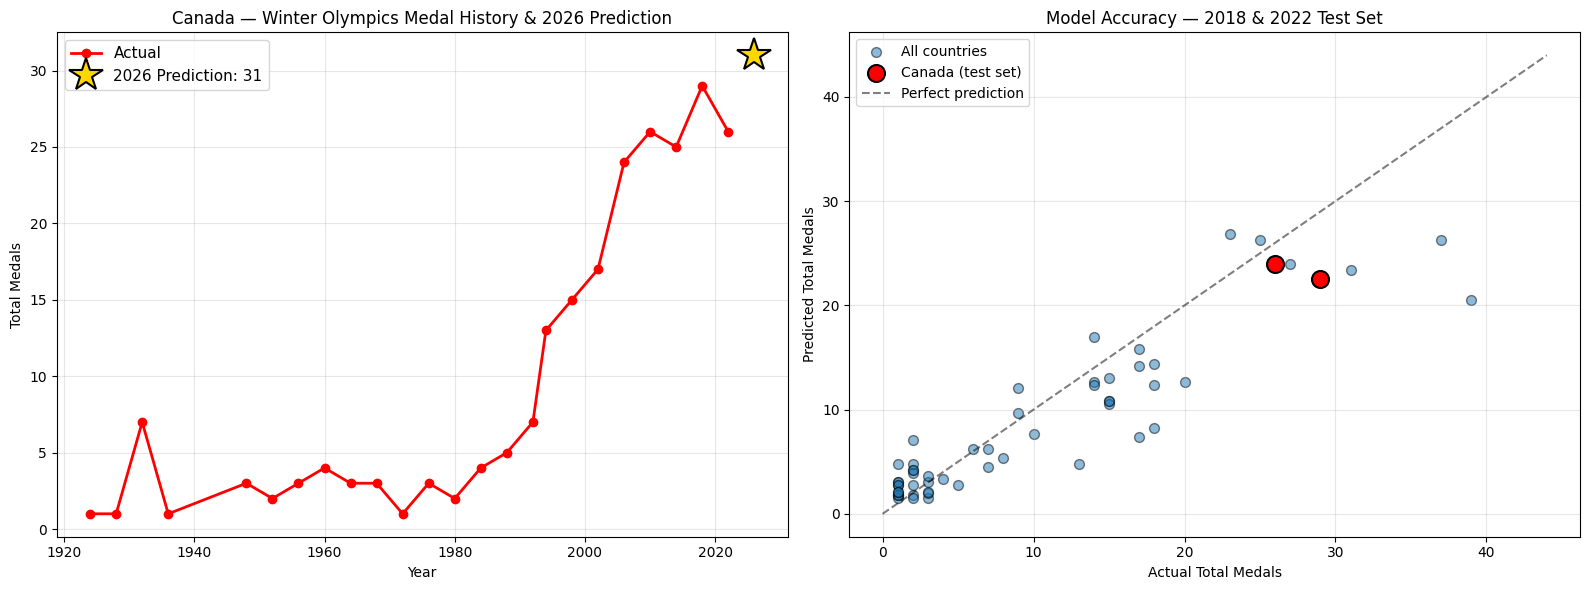

In [ ]:
# Canada's medal trajectory + 2026 prediction

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Historical trajectory + prediction ---
canada_hist = canada[['year', 'total']].dropna()

axes[0].plot(canada_hist['year'], canada_hist['total'], 'o-',
             color='red', linewidth=2, markersize=6, label='Actual')
axes[0].plot(2026, round(prediction_2026), '*', color='gold',
             markersize=25, markeredgecolor='black', markeredgewidth=1.5,
             label=f'2026 Prediction: {round(prediction_2026)}', zorder=5)

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Medals')
axes[0].set_title("Canada — Winter Olympics Medal History & 2026 Prediction")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Model performance context ---
axes[1].scatter(y_test, final_preds, alpha=0.5, edgecolors='black', s=50, label='All countries')

canada_mask = df_test['country_noc'] == 'CAN'
axes[1].scatter(y_test[canada_mask], final_preds[canada_mask.values],
                color='red', s=150, zorder=5, label='Canada (test set)',
                edgecolors='black', linewidth=1.5)

max_val = max(y_test.max(), final_preds.max()) + 5
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')

axes[1].set_xlabel('Actual Total Medals')
axes[1].set_ylabel('Predicted Total Medals')
axes[1].set_title('Model Accuracy — 2018 & 2022 Test Set')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.5 Prediction Summary

| Item | Value |
|:-----|:------|
| **Model** | Linear Regression (3 features) |
| **Test MAE** | 3.10 medals |
| **Test R²** | 0.798 |
| **2026 Host** | Italy (Milan-Cortina) |
| **Canada is Host** | No |
| **Prediction** | See output above |

The model relies on three interpretable signals:
1. **Historical strength** (`rolling_avg_total_3`): How well has Canada performed in the last 3 Olympics?
2. **Delegation investment** (`unique_female_count`): How large and diverse is the team?
3. **Host advantage** (`is_host_int`): Is there a home-field boost?

In [ ]:
# Final model equation with actual coefficient values

print(f"Predicted Medals = {final_model.intercept_:.4f}")
for feat, coef in zip(final_features, final_model.coef_):
    sign = "+" if coef >= 0 else "-"
    val = canada_2026[feat].values[0]
    print(f"  {sign} {abs(coef):.4f} x {feat} ({val:.1f})")
print(f"\n  = {prediction_2026:.1f} total medals")

Predicted Medals = 0.6806
  + 0.0649 x unique_female_count (106.0)
  + 3.8628 x is_host_int (0.0)
  + 0.8732 x rolling_avg_total_3 (26.7)

  = 30.8 total medals


In [ ]:
# Context: How does 31 medals compare to Canada's history?

canada_hist = canada[['year', 'total']].dropna()

print("Canada's Winter Olympics Medal History:\n")
print(canada_hist.to_string(index=False))

print(f"\n{'=' * 45}")
print(f"  Historical Stats:")
print(f"  Last 3 Olympics avg:  {canada_2026['rolling_avg_total_3'].values[0]:.1f}")
print(f"  2014 Sochi:           {canada_2014['total']:.0f}")
print(f"  2018 PyeongChang:     {canada_2018['total']:.0f}")
print(f"  2022 Beijing:         {canada_2022['total']:.0f}")
print(f"{'=' * 45}")
print(f"  2026 Prediction:      {round(prediction_2026)}")
print(f"  Confidence range:     {round(prediction_2026) - 3} to {round(prediction_2026) + 3}")
print(f"  (based on MAE = 3.10)")
print(f"{'=' * 45}")

Canada's Winter Olympics Medal History:

 year  total
 1924      1
 1928      1
 1932      7
 1936      1
 1948      3
 1952      2
 1956      3
 1960      4
 1964      3
 1968      3
 1972      1
 1976      3
 1980      2
 1984      4
 1988      5
 1992      7
 1994     13
 1998     15
 2002     17
 2006     24
 2010     26
 2014     25
 2018     29
 2022     26

  Historical Stats:
  Last 3 Olympics avg:  26.7
  2014 Sochi:           25
  2018 PyeongChang:     29
  2022 Beijing:         26
  2026 Prediction:      31
  Confidence range:     28 to 34
  (based on MAE = 3.10)


### Interpretation

The model predicts Canada will win approximately **31 medals** at the 2026 Winter Olympics, which is **above their recent 3-Olympics average of ~27 medals**.

Given our model's MAE of 3.10, a realistic confidence range would be:


$$
31 \pm 3 \approx \textbf{28 to 34 medals}
$$


| Metric | Value |
|:-------|:------|
| **Point prediction** | 31 medals |
| **Confidence range** | 28 — 34 medals |
| **Recent average (2014-2022)** | ~27 medals |
| **Model error margin** | ± 3 medals |

#### Why Slightly Above Average?

The model accounts for:
1. **Strong recent trajectory:** Canada's rolling average of 26.7 provides a high baseline.
2. **Delegation size:** 106 female athletes reflects a strong, well-invested team — the model adds a small boost for larger delegations.
3. **No host penalty:** Canada is not hosting, so no artificial boost — but also no pressure of expectation.

#### Caveats
- The prediction assumes Canada sends a **similar-sized delegation** to 2022.
- External factors (injuries, new talent, event additions) are **not captured** by the model.
- The confidence range is a **rough estimate** based on MAE, not a formal confidence interval.